# Linear Discriminant Analysis (LDA) from Scratch

## Objectives

- Understand the intuition behind LDA.
- Implement LDA using NumPy.
- Calculate within-class and between-class scatter matrices.
- Find discriminant directions using eigenvectors.
- Reduce the dataset to lower dimensions.
- Compare the implementation with Scikit-Learn.

## LDA Intuition

Linear Discriminant Analysis is a supervised dimensionality-reduction
technique.

Unlike PCA, LDA uses class labels to find directions that:

- Maximize separation between different classes.
- Minimize variation within the same class.

LDA uses two important matrices:

1. Within-Class Scatter Matrix (S_W)
2. Between-Class Scatter Matrix (S_B)

The objective is to find directions that maximize:

    S_W⁻¹ S_B

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
data = load_wine()

X = data.data
y = data.target

df = pd.DataFrame(
    X,
    columns=data.feature_names
)

df["Target"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)
print("Number of classes:", len(np.unique(y)))

Original shape: (178, 13)
Scaled shape: (178, 13)
Number of classes: 3


In [4]:
class LDAScratch:

    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components_ = None
        self.eigenvalues_ = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        classes = np.unique(y)

        self.mean = np.mean(X, axis=0)

        n_features = X.shape[1]

        within_scatter = np.zeros(
            (n_features, n_features)
        )

        between_scatter = np.zeros(
            (n_features, n_features)
        )

        # Within-class scatter
        for cls in classes:

            X_class = X[y == cls]

            class_mean = np.mean(
                X_class,
                axis=0
            )

            centered = X_class - class_mean

            within_scatter += (
                centered.T @ centered
            )

        # Between-class scatter
        for cls in classes:

            X_class = X[y == cls]

            class_mean = np.mean(
                X_class,
                axis=0
            )

            n_class = len(X_class)

            mean_difference = (
                class_mean - self.mean
            ).reshape(-1, 1)

            between_scatter += (
                n_class *
                (mean_difference @ mean_difference.T)
            )

        # Solve generalized eigenvalue problem
        matrix = (
            np.linalg.pinv(within_scatter)
            @ between_scatter
        )

        eigenvalues, eigenvectors = np.linalg.eig(
            matrix
        )

        eigenvalues = np.real(eigenvalues)
        eigenvectors = np.real(eigenvectors)

        sorted_indices = np.argsort(
            eigenvalues
        )[::-1]

        eigenvalues = eigenvalues[
            sorted_indices
        ]

        eigenvectors = eigenvectors[
            :, sorted_indices
        ]

        max_components = min(
            len(classes) - 1,
            n_features
        )

        self.eigenvalues_ = eigenvalues[
            :max_components
        ]

        self.components_ = eigenvectors[
            :, :max_components
        ]

        return self

    def transform(self, X):
        X = np.asarray(X)

        X_centered = X - self.mean

        return X_centered @ self.components_

    def fit_transform(self, X, y):
        self.fit(X, y)

        return self.transform(X)

In [5]:
lda = LDAScratch(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_lda.shape)

print("\nEigenvalues:")
print(lda.eigenvalues_)

Original shape: (178, 13)
Reduced shape: (178, 2)

Eigenvalues:
[9.08173944 4.12846905]


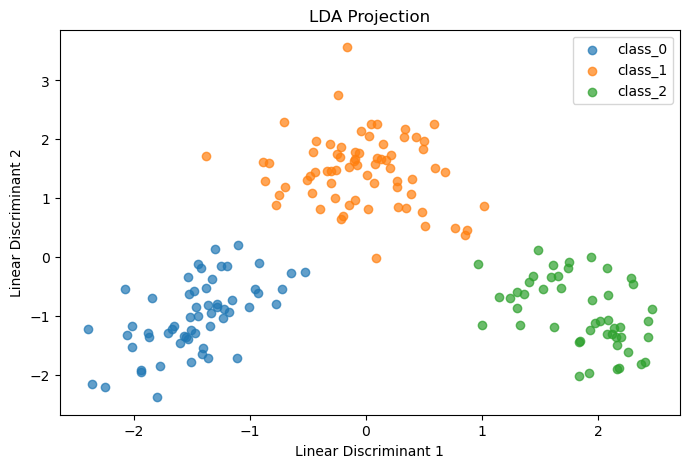

In [6]:
plt.figure(figsize=(8, 5))

for cls in np.unique(y):

    plt.scatter(
        X_lda[y == cls, 0],
        X_lda[y == cls, 1],
        label=data.target_names[cls],
        alpha=0.7
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA Projection")
plt.legend()

plt.show()

In [7]:
explained = (
    lda.eigenvalues_
    / np.sum(lda.eigenvalues_)
)

lda_variance = pd.DataFrame({
    "Component": [
        f"LD{i + 1}"
        for i in range(len(explained))
    ],
    "Relative Importance": explained
})

lda_variance

,Component,Relative Importance
0,LD1,0.687479
1,LD2,0.312521


In [8]:
sklearn_lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_sklearn = sklearn_lda.fit_transform(
    X_scaled,
    y
)

print("Scikit-Learn reduced shape:")
print(X_sklearn.shape)

print("\nExplained variance ratio:")
print(sklearn_lda.explained_variance_ratio_)

Scikit-Learn reduced shape:
(178, 2)

Explained variance ratio:
[0.68747889 0.31252111]


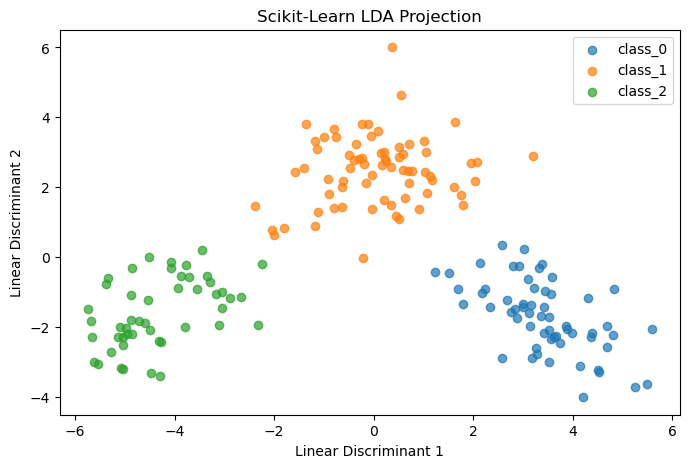

In [9]:
plt.figure(figsize=(8, 5))

for cls in np.unique(y):

    plt.scatter(
        X_sklearn[y == cls, 0],
        X_sklearn[y == cls, 1],
        label=data.target_names[cls],
        alpha=0.7
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("Scikit-Learn LDA Projection")
plt.legend()

plt.show()

In [10]:
comparison = pd.DataFrame({
    "Component": ["LD1", "LD2"],
    "From Scratch": explained,
    "Scikit-Learn": sklearn_lda.explained_variance_ratio_
})

comparison

,Component,From Scratch,Scikit-Learn
0,LD1,0.687479,0.687479
1,LD2,0.312521,0.312521


## PCA vs LDA

| PCA | LDA |
|---|---|
| Unsupervised | Supervised |
| Does not use labels | Uses class labels |
| Maximizes variance | Maximizes class separation |
| Useful for general dimensionality reduction | Useful for classification-oriented reduction |
| Components are based on overall variance | Components are based on between/within-class variation |

## Conclusion

- LDA is a supervised dimensionality-reduction technique.
- It uses class information to find discriminative directions.
- Within-class scatter measures variation within each class.
- Between-class scatter measures separation between class means.
- LDA can produce at most `number_of_classes - 1` components.
- The from-scratch implementation demonstrates the mathematical foundation
  behind LDA.